# Benchmark Results

compare trained flow runs against baseline predictors using the benchmark api

outputs
- per group metric dataframe
- reduced summary dataframe
- box and whisker plots over grouped metrics


In [1]:
%env PYTORCH_ENABLE_MPS_FALLBACK=1


env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from flatcfm.analysis import run_benchmark_suite, validate_run_dirs, aggregate_over_runs, format_mean_std_table

In [3]:
# experiments = [
#     "sciplex_deg_baseline_no_effect",
#     "sciplex_deg_baseline_context_mean",
#     "sciplex_deg_baseline_perturb_mean",
#     "sciplex_deg_baseline_additive",
#     "sciplex_deg_baseline_latent_additive",
#     "sciplex_deg_baseline_decoder",
#     "sciplex_deg_baseline_linear",
#     "sciplex_fm_deg_log1p",
#     "sciplex_fm_deg_ae_latent_recon",
#     "sciplex_fm_deg_ae_latent_hybrid",
#     "sciplex_fm_deg_ae_latent_phate_cosine",
#     "sciplex_fm_deg_ae_latent_mse_d512",
#     "sciplex_fm_deg_ae_latent_phate",
#     "sciplex_fm_deg_pca",
#     "sciplex_ode_deg_log1p",
#     "sciplex_ode_deg_pca",
#     "sciplex_ode_deg_ae_latent_mse_d512",
#     "sciplex_fisher_flow_composition",
#     "sciplex_fm_deg_ae_latent_nb_pullback",
# ]

experiments = [
    "sciplex_deg_baseline_no_effect",
    "sciplex_deg_baseline_decoder",
    "sciplex_deg_baseline_linear",
    "sciplex_deg_baseline_context_mean",
    "sciplex_deg_baseline_perturb_mean",
    "sciplex_deg_baseline_additive",
    "sciplex_deg_baseline_latent_additive",
    "sciplex_fm_deg_ae_latent_mse_d512",
    "sciplex_ode_deg_ae_latent_mse_d512",
    # "sciplex_fm_deg_ae_latent_hybrid",
    # "sciplex_fm_deg_ae_latent_phate",
    # "sciplex_ode_deg_ae_latent_phate",
    "sciplex_fm_deg_pca_d16",
    "sciplex_ode_deg_pca_d16",
    "sciplex_fm_deg_geom_reg_w10",
    "sciplex_fm_deg_geom_reg_w0p0001",
    # "sciplex_fm_deg_pca_d16_hpo",
    # "sciplex_ode_deg_pca_d16_hpo",
]


validate_run_dirs(experiments)
print("all runs compatible")

metrics = ["mean_gene_w1", "w2_squared", "cosine_log_fc", "mmd"]
group_columns = ["cell_type", "product_dose"]
reductions = ["unweighted_mean", "cell_weighted_mean"]

all runs compatible


In [4]:
# run base metrics in comparison space
result = run_benchmark_suite(
    {
        "experiments": experiments,
        "metrics": ["mean_gene_w1", "w2_squared", "cosine_log_fc"],
        "group_columns": group_columns,
        "reductions": reductions,
        "all_runs": True,
    }
)

# run mmd in pca-50 space
result_pca = run_benchmark_suite(
    {
        "experiments": experiments,
        "metrics": ["mmd"],
        "group_columns": group_columns,
        "reductions": reductions,
        "all_runs": True,
        "metric_spaces": [
            {"name": "train_pca_50", "kind": "train_pca", "pca_n_components": 50},
        ],
    }
)

per_group_metrics = pd.concat([result["per_group_metrics"], result_pca["per_group_metrics"]], ignore_index=True)
summary_metrics = pd.concat([result["summary_metrics"], result_pca["summary_metrics"]], ignore_index=True)

print(f"anchor run dir: {result['anchor_run_dir']}")
print(f"n predictors: {len(result['predictions'])}")
print(f"per group rows: {len(per_group_metrics)}")
print(f"summary rows: {len(summary_metrics)}")

/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/dac227/project_pi_sk2433/dac227/FlatCFM/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1811: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/da

anchor run dir: /nfs/roberts/project/pi_sk2433/dac227/FlatCFM/artifacts/runs/sciplex_deg_baseline_no_effect/20260315_210043
n predictors: 13
per group rows: 19500
summary rows: 104


In [5]:
display(summary_metrics.head(20))

if summary_metrics.empty:
    print("summary metrics is empty")
else:
    summary_table = summary_metrics.pivot_table(
        index=["model_name", "metric_space", "reduction"],
        columns="metric",
        values="value",
        aggfunc="first",
    ).reset_index()
    summary_table.columns.name = None
    display(summary_table)


,model_name,metric,metric_base,category,aggregation,metric_space,metric_space_label,prediction_name,reduction,value,n_groups
0,sciplex_deg_baseline_no_effect,cosine_log_fc,cosine_log_fc,profile,logfc,comparison,normalized_log1p,held_out,unweighted_mean,-0.002534,375
1,sciplex_deg_baseline_no_effect,cosine_log_fc,cosine_log_fc,profile,logfc,comparison,normalized_log1p,held_out,cell_weighted_mean,-0.001666,375
2,sciplex_deg_baseline_no_effect,mean_gene_w1,mean_gene_w1,cell_distribution,none,comparison,normalized_log1p,held_out,unweighted_mean,0.101633,375
3,sciplex_deg_baseline_no_effect,mean_gene_w1,mean_gene_w1,cell_distribution,none,comparison,normalized_log1p,held_out,cell_weighted_mean,0.094718,375
4,sciplex_deg_baseline_no_effect,w2_squared,w2_squared,cell_distribution,none,comparison,normalized_log1p,held_out,unweighted_mean,4064.367531,375
5,sciplex_deg_baseline_no_effect,w2_squared,w2_squared,cell_distribution,none,comparison,normalized_log1p,held_out,cell_weighted_mean,4052.348339,375
6,sciplex_deg_baseline_decoder,cosine_log_fc,cosine_log_fc,profile,logfc,comparison,normalized_log1p,held_out,unweighted_mean,0.183571,375
7,sciplex_deg_baseline_decoder,cosine_log_fc,cosine_log_fc,profile,logfc,comparison,normalized_log1p,held_out,cell_weighted_mean,0.192654,375
8,sciplex_deg_baseline_decoder,mean_gene_w1,mean_gene_w1,cell_distribution,none,comparison,normalized_log1p,held_out,unweighted_mean,0.276341,375
9,sciplex_deg_baseline_decoder,mean_gene_w1,mean_gene_w1,cell_distribution,none,comparison,normalized_log1p,held_out,cell_weighted_mean,0.276371,375


,model_name,metric_space,reduction,cosine_log_fc,mean_gene_w1,mmd,w2_squared
0,sciplex_deg_baseline_additive,comparison,cell_weighted_mean,0.018188,0.111575,NaN,4057.225880
1,sciplex_deg_baseline_additive,comparison,unweighted_mean,0.017325,0.118404,NaN,4068.377377
2,sciplex_deg_baseline_additive,train_pca_50,cell_weighted_mean,NaN,NaN,0.046180,NaN
3,sciplex_deg_baseline_additive,train_pca_50,unweighted_mean,NaN,NaN,0.058127,NaN
4,sciplex_deg_baseline_context_mean,comparison,cell_weighted_mean,0.085189,0.290739,NaN,2202.363470
5,sciplex_deg_baseline_context_mean,comparison,unweighted_mean,0.088701,0.290680,NaN,2202.512792
6,sciplex_deg_baseline_context_mean,train_pca_50,cell_weighted_mean,NaN,NaN,0.297201,NaN
7,sciplex_deg_baseline_context_mean,train_pca_50,unweighted_mean,NaN,NaN,0.305713,NaN
8,sciplex_deg_baseline_decoder,comparison,cell_weighted_mean,0.192654,0.276371,NaN,2165.976502
9,sciplex_deg_baseline_decoder,comparison,unweighted_mean,0.183571,0.276341,NaN,2167.519519


/tmp/ipykernel_166216/424422023.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.30, 1, 0.94))


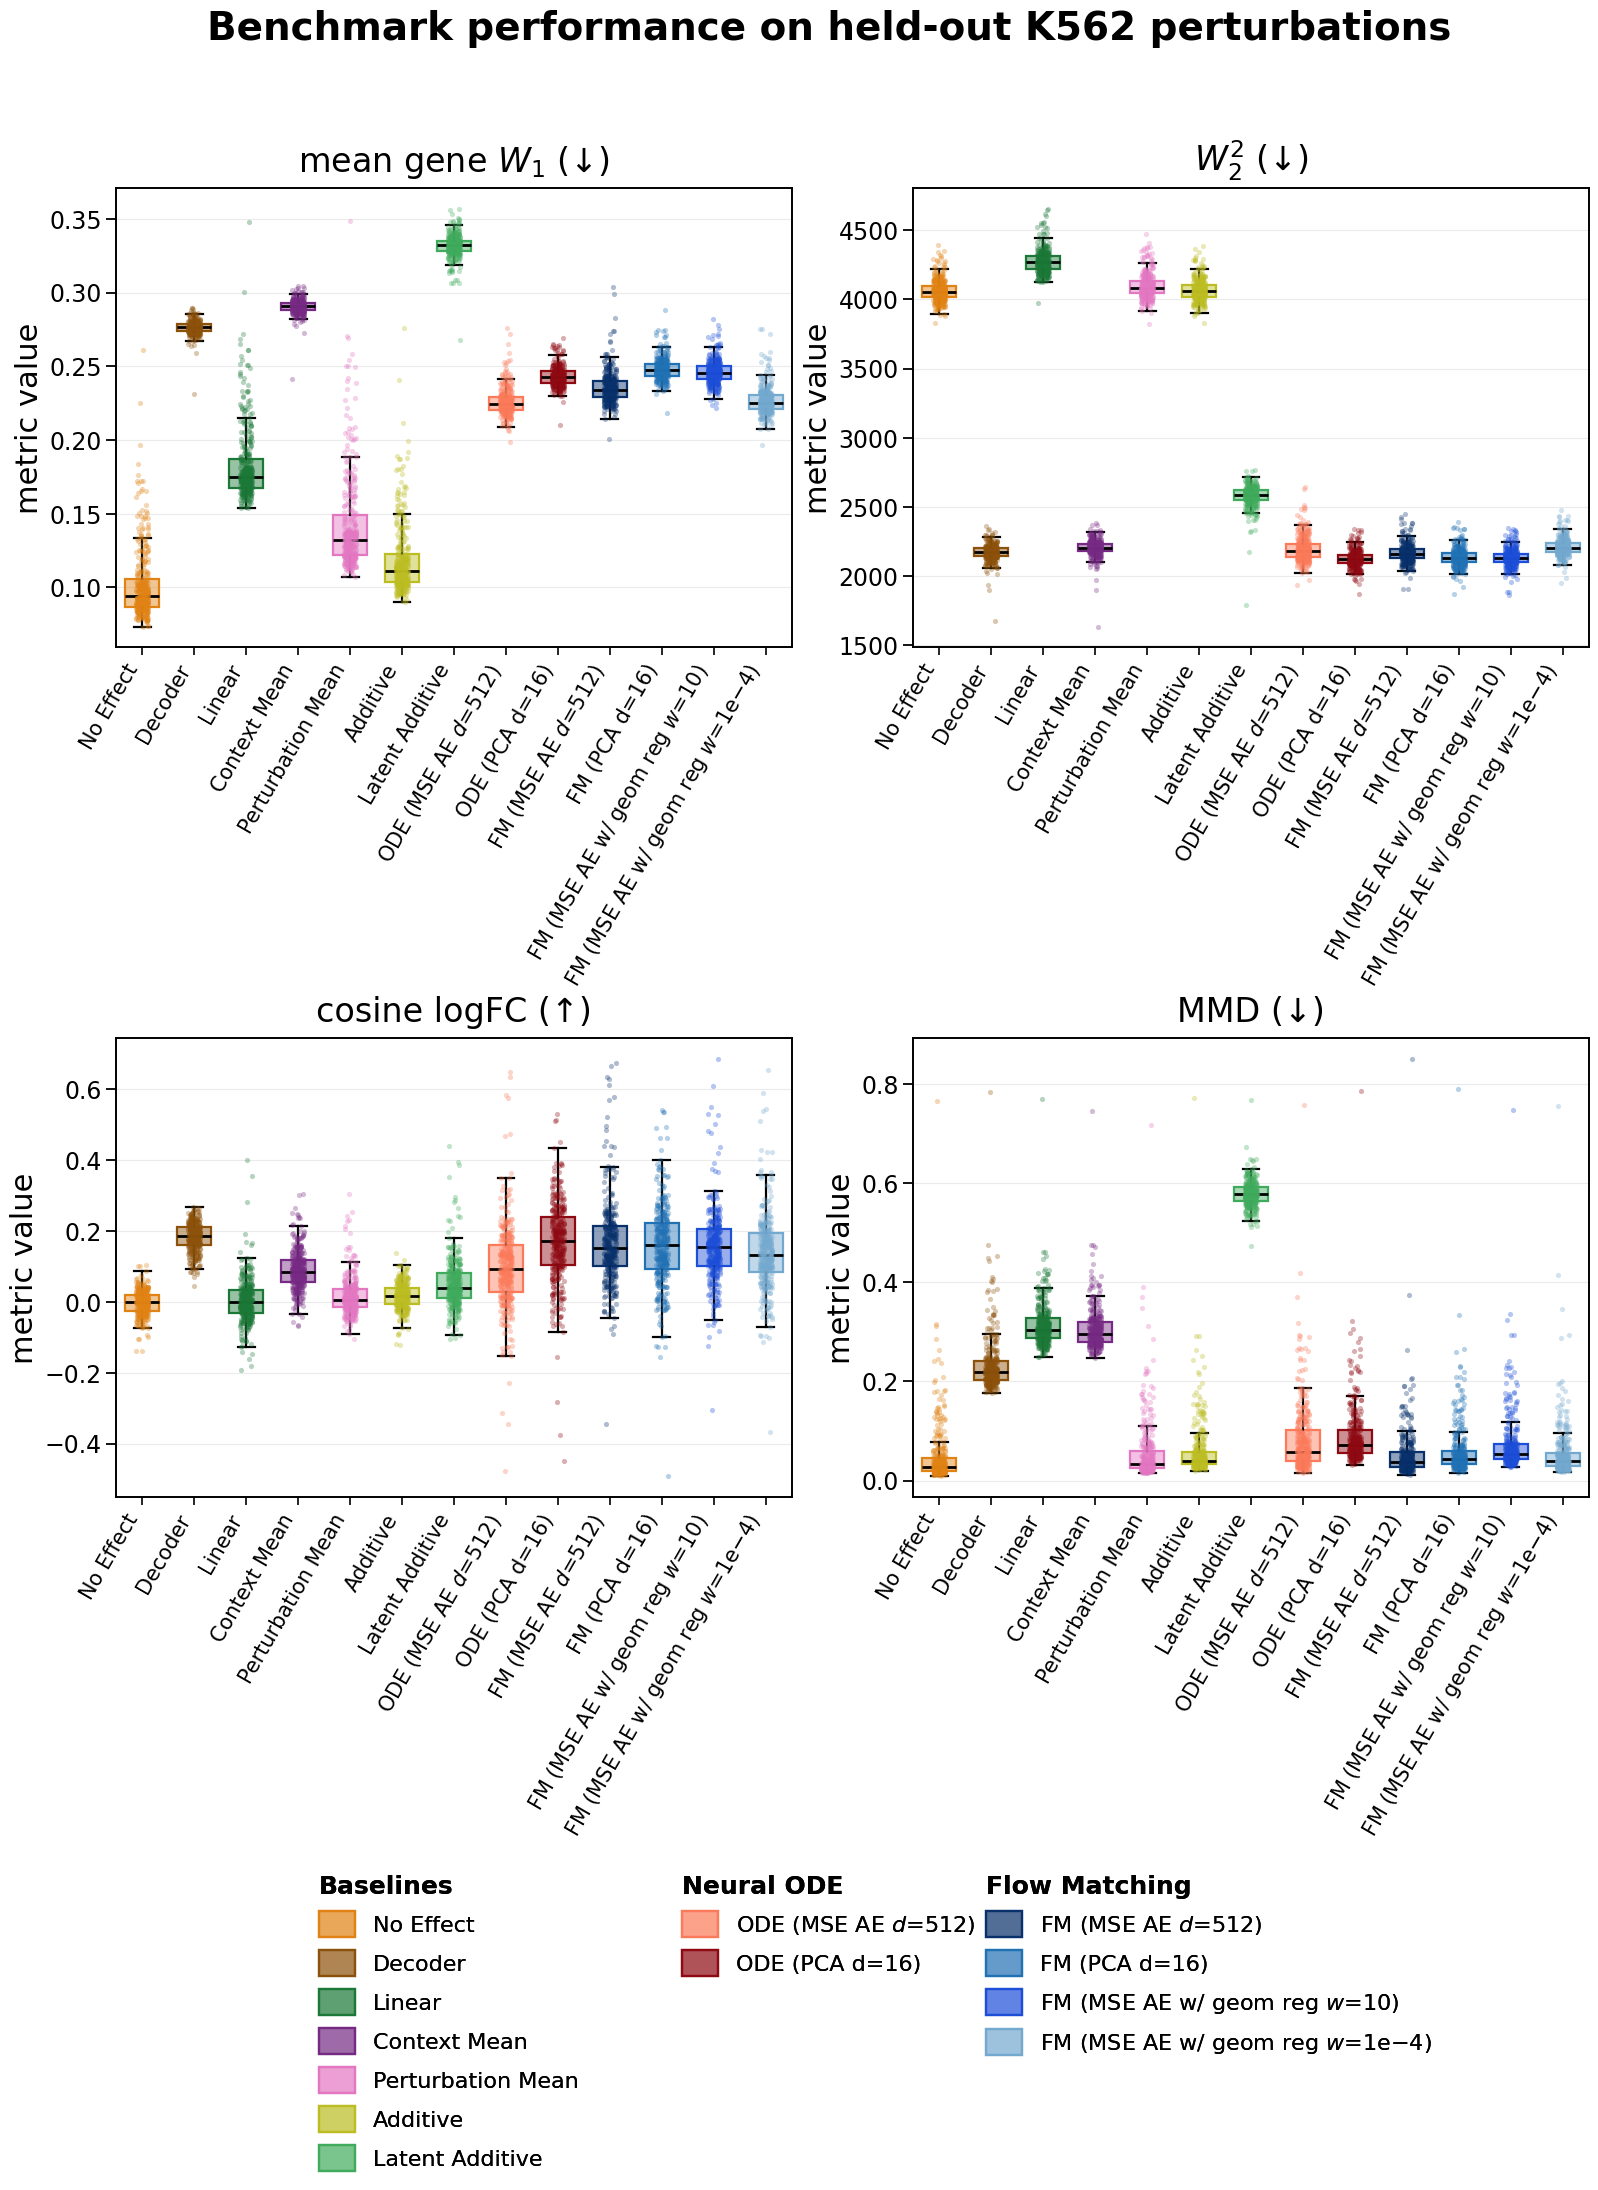

In [ ]:
# poster-ready boxplots larger fonts thicker lines per-model colors
# 2x2 grid one metric per subplot models on x-axis box per model with
# scatter overlay of per-group values
#
# color scheme each family is its own hue family but every model gets
# a distinct shade
#   FM models     a categorical set of distinct blues navy royal sky etc
#                 not a smooth gradient so adjacent boxes read apart
#   ODE models    varying reds from the Reds colormap
#   baselines     distinct categorical hues (orange brown green purple
#                 pink olive) deliberately no cyan/teal which would read
#                 as a desaturated blue and collide with the FM family
from pathlib import Path

import numpy as np
from matplotlib.patches import Patch

MODEL_DISPLAY_NAMES = {
    "sciplex_deg_baseline_no_effect": "No Effect",
    "sciplex_deg_baseline_context_mean": "Context Mean",
    "sciplex_deg_baseline_perturb_mean": "Perturbation Mean",
    "sciplex_deg_baseline_additive": "Additive",
    "sciplex_deg_baseline_latent_additive": "Latent Additive",
    "sciplex_deg_baseline_decoder": "Decoder",
    "sciplex_deg_baseline_linear": "Linear",
    "sciplex_fm_deg_log1p": "FM (log1p)",
    "sciplex_fm_deg_pca": "FM (PCA)",
    "sciplex_fm_deg_pca_d16": "FM (PCA d=16)",
    "sciplex_fm_deg_ae_latent_mse_d512": r"FM (MSE AE $d$=512)",
    "sciplex_fm_deg_ae_latent_hybrid": "FM (Hybrid AE)",
    "sciplex_fm_deg_ae_latent_phate": "FM (PHATE AE)",
    "sciplex_fm_deg_ae_latent_phate_cosine": "FM (PHATE Cosine AE)",
    "sciplex_fm_deg_ae_latent_nb_pullback": "FM (NB AE)",
    "sciplex_fm_deg_ae_latent_recon": "FM (Recon AE)",
    "sciplex_fisher_flow_composition": "Fisher Flow",
    "sciplex_ode_deg_log1p": "ODE (log1p)",
    "sciplex_ode_deg_pca": "ODE (PCA)",
    "sciplex_ode_deg_pca_d16": "ODE (PCA d=16)",
    "sciplex_ode_deg_ae_latent_mse_d512": r"ODE (MSE AE $d$=512)",
    # geom reg sweep picks
    "sciplex_fm_deg_geom_reg_w10": r"FM (MSE AE w/ geom reg $w$=10)",
    "sciplex_fm_deg_geom_reg_w0p0001": r"FM (MSE AE w/ geom reg $w$=1e$-$4)",
    "sciplex_ode_deg_geom_reg_w10": r"ODE (MSE AE w/ geom reg $w$=10)",
}


def _display_name(model_name: str) -> str:
    return MODEL_DISPLAY_NAMES.get(model_name, model_name)


def _group_for(name: str) -> str:
    if "baseline" in name:
        return "baseline"
    if "fisher_flow" in name:
        return "fm"
    if "_ode_" in name or "_ode" in name:
        return "ode"
    return "fm"


# baseline palette categorical hues outside the blue and red families
# no cyan/teal since that reads as a desaturated blue and would collide
# with the FM family
_BASELINE_PALETTE = [
    "#e08214",  # orange
    "#8c510a",  # brown
    "#1b7837",  # dark green
    "#762a83",  # purple
    "#e377c2",  # pink
    "#bcbd22",  # olive
    "#41ab5d",  # medium green
    "#7f3b08",  # dark brown
    "#c994c7",  # light purple
]

# FM palette hand-picked distinct blues rather than a smooth gradient
# so adjacent FM boxes do not blur together covers navy cobalt royal
# sky steel deep slate bright blue and indigo
_FM_PALETTE = [
    "#08306b",  # very dark navy
    "#2171b5",  # cobalt
    "#1d4ed8",  # royal blue
    "#74a9cf",  # sky blue
    "#0c4a6e",  # deep slate blue
    "#3b82f6",  # bright blue
    "#a8c5e9",  # pale steel blue
    "#1e40af",  # indigo blue
]

_GROUP_LABEL = {"baseline": "Baselines", "fm": "Flow Matching", "ode": "Neural ODE"}


def _shade_palette(cmap, n: int, lo: float = 0.45, hi: float = 0.92):
    """sample n shades from cmap between lo and hi spanning dark to light
    avoids the very light end of sequential maps so boxes stay readable
    on white backgrounds returns rgba tuples
    """
    if n <= 1:
        return [cmap(0.7)]
    return [cmap(lo + (hi - lo) * i / (n - 1)) for i in range(n)]


def _build_model_colors(models):
    """assign each model a color by family

    baselines and FM use hand-picked categorical palettes so within-
    family hues are clearly distinguishable ODE uses sequential reds
    sampled from plt.cm.Reds within-family ordering follows the input
    list (already sorted by experiments order)
    """
    by_group = {"baseline": [], "fm": [], "ode": []}
    for m in models:
        by_group[_group_for(m)].append(m)
    ode_palette = _shade_palette(plt.cm.Reds, len(by_group["ode"]))
    colors = {}
    for i, m in enumerate(by_group["baseline"]):
        colors[m] = _BASELINE_PALETTE[i % len(_BASELINE_PALETTE)]
    for i, m in enumerate(by_group["fm"]):
        colors[m] = _FM_PALETTE[i % len(_FM_PALETTE)]
    for i, m in enumerate(by_group["ode"]):
        colors[m] = ode_palette[i]
    return colors


metric_pretty = {
    "mean_gene_w1": r"mean gene $W_1$",
    "w2_squared": r"$W_2^2$",
    "cosine_log_fc": "cosine logFC",
    "mmd": "MMD",
}
metric_direction_arrow = {
    "mean_gene_w1": "↓",
    "w2_squared": "↓",
    "cosine_log_fc": "↑",
    "mmd": "↓",
}
metric_direction = {
    "mean_gene_w1": "↓ lower is better",
    "w2_squared": "↓ lower is better",
    "cosine_log_fc": "↑ higher is better",
    "deg_jaccard": "↑ higher is better",
    "top_k_recall": "↑ higher is better",
    "mmd": "↓ lower is better",
}

if per_group_metrics.empty:
    print("no per group metrics to plot")
else:
    plot_metrics = [
        m for m in metrics if m in set(per_group_metrics["metric_base"]) or m in set(per_group_metrics["metric"])
    ]
    plot_metric_names = []
    for metric in plot_metrics:
        subset = per_group_metrics[per_group_metrics["metric_base"] == metric]
        if subset.empty:
            subset = per_group_metrics[per_group_metrics["metric"] == metric]
        if not subset.empty:
            plot_metric_names.append(metric)

    # order models by group then by experiments list order so colored
    # blocks of baselines ODE FM are contiguous along the x-axis
    exp_order = {name: i for i, name in enumerate(experiments)}
    group_order = {"baseline": 0, "ode": 1, "fm": 2}
    all_models = sorted(
        per_group_metrics["model_name"].unique().tolist(),
        key=lambda n: (group_order.get(_group_for(n), 9), exp_order.get(n, 1e9), n),
    )
    model_colors = _build_model_colors(all_models)

    n_metrics = len(plot_metric_names)
    n_cols = 2 if n_metrics >= 2 else 1
    n_rows = (n_metrics + n_cols - 1) // n_cols

    with plt.rc_context(
        {
            "font.size": 18,
            "axes.titlesize": 24,
            "axes.labelsize": 22,
            "xtick.labelsize": 15,
            "ytick.labelsize": 17,
            "legend.fontsize": 16,
            "legend.title_fontsize": 18,
            "axes.linewidth": 1.6,
            "lines.linewidth": 2.2,
            "lines.markersize": 8,
        }
    ):
        # generous figsize so rotated tick labels and the legend strip
        # have room without shrinking the axes
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(9.5 * n_cols, 8.5 * n_rows),
            gridspec_kw={"wspace": 0.18, "hspace": 0.85},
        )
        axes = np.atleast_1d(axes).flatten()

        rng = np.random.default_rng(0)
        for ax, metric in zip(axes, plot_metric_names):
            subset = per_group_metrics[per_group_metrics["metric_base"] == metric].copy()
            if subset.empty:
                subset = per_group_metrics[per_group_metrics["metric"] == metric].copy()
            models = [m for m in all_models if m in set(subset["model_name"])]
            data = [subset.loc[subset["model_name"] == name, "value"].dropna().to_numpy() for name in models]
            colors = [model_colors[name] for name in models]

            bp = ax.boxplot(
                data,
                labels=[_display_name(m) for m in models],
                patch_artist=True,
                widths=0.65,
                showfliers=False,
                medianprops=dict(color="black", linewidth=2.0),
                whiskerprops=dict(linewidth=1.6),
                capprops=dict(linewidth=1.6),
                boxprops=dict(linewidth=1.6),
            )
            for patch, color in zip(bp["boxes"], colors):
                patch.set_facecolor((*plt.matplotlib.colors.to_rgb(color), 0.45))
                patch.set_edgecolor(color)
            for idx, (values, color) in enumerate(zip(data, colors), start=1):
                x = np.full(len(values), idx) + rng.uniform(-0.12, 0.12, size=len(values))
                ax.scatter(x, values, s=14, alpha=0.32, color=color, linewidths=0, zorder=3)

            arrow = metric_direction_arrow.get(metric, "")
            pretty = metric_pretty.get(metric, metric)
            ax.set_title(f"{pretty} ({arrow})", pad=12)
            ax.set_ylabel("metric value")
            ax.tick_params(axis="x", rotation=60, length=6, width=1.2)
            ax.tick_params(axis="y", length=7, width=1.3)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment("right")
            ax.grid(alpha=0.25, linewidth=0.8, axis="y")
            for spine in ax.spines.values():
                spine.set_linewidth(1.4)

        for ax in axes[n_metrics:]:
            ax.set_visible(False)

        # three separate legends one per family (baselines / ODE / FM)
        # placed side-by-side below the axes each is its own column with
        # a bold title fig.add_artist on each previous legend keeps them
        # all on the figure (otherwise later fig.legend calls can replace
        # earlier ones in some matplotlib versions)
        def _make_handles(models_g):
            return [
                Patch(
                    facecolor=(*plt.matplotlib.colors.to_rgb(model_colors[m]), 0.45),
                    edgecolor=model_colors[m],
                    linewidth=1.6,
                    label=_display_name(m),
                )
                for m in models_g
            ]

        legend_groups = [
            ("Baselines", [m for m in all_models if _group_for(m) == "baseline"]),
            ("Neural ODE", [m for m in all_models if _group_for(m) == "ode"]),
            ("Flow Matching", [m for m in all_models if _group_for(m) == "fm"]),
        ]
        legend_groups = [(t, ms) for t, ms in legend_groups if ms]

        # legend pushed well below the figure bottom by anchoring with a
        # negative y value bbox_inches="tight" on savefig still includes
        # it and trims any extra whitespace around it
        fig.tight_layout(rect=(0, 0.30, 1, 0.94))

        # cluster the group columns near figure center smaller spread
        # value packs them tighter together
        n_groups = len(legend_groups)
        legend_spread = 0.4
        if n_groups == 1:
            group_centers = [0.5]
        else:
            group_centers = [0.5 + (i - (n_groups - 1) / 2) * (legend_spread / (n_groups - 1)) for i in range(n_groups)]

        for (title, models_g), x in zip(legend_groups, group_centers):
            leg = fig.legend(
                handles=_make_handles(models_g),
                title=title,
                loc="upper center",
                ncol=1,
                bbox_to_anchor=(x, -0.10),
                frameon=False,
                handlelength=1.6,
                handleheight=1.4,
                columnspacing=2.8,
                labelspacing=0.6,
                alignment="left",
            )
            leg.get_title().set_fontweight("bold")
            fig.add_artist(leg)

        fig.suptitle(
            "Benchmark performance on held-out K562 perturbations",
            fontsize=28,
            fontweight="bold",
            y=0.985,
        )

        Path("figures").mkdir(exist_ok=True)
        plt.show()
        fig.savefig("figures/benchmark_results_poster.svg", bbox_inches="tight")
        fig.savefig("figures/benchmark_results_poster.pdf", bbox_inches="tight")


In [7]:
import numpy as np

# which direction is "best" for each metric
metric_lower_is_better = {
    "mean_gene_w1": True,
    "w2_squared": True,
    "cosine_log_fc": False,
    "deg_jaccard": False,
    "top_k_recall": False,
}

if not per_group_metrics.empty:
    models = sorted(per_group_metrics["model_name"].unique().tolist())
    rows = []
    for metric in plot_metric_names:
        subset = per_group_metrics[per_group_metrics["metric_base"] == metric]
        if subset.empty:
            subset = per_group_metrics[per_group_metrics["metric"] == metric]
        for model in models:
            vals = subset.loc[subset["model_name"] == model, "value"].dropna()
            rows.append({"model": model, "metric": metric, "mean": vals.mean(), "std": vals.std()})

    tbl = pd.DataFrame(rows)
    pivot_mean = tbl.pivot(index="model", columns="metric", values="mean")
    pivot_std = tbl.pivot(index="model", columns="metric", values="std")

    # find best model per metric
    best = {}
    for metric in plot_metric_names:
        if metric_lower_is_better.get(metric, True):
            best[metric] = pivot_mean[metric].idxmin()
        else:
            best[metric] = pivot_mean[metric].idxmax()

    # format as mean +/- std
    display_df = pd.DataFrame(index=pivot_mean.index)
    for metric in plot_metric_names:
        arrow = "\u2193" if metric_lower_is_better.get(metric, True) else "\u2191"
        display_df[f"{metric} ({arrow})"] = [
            f"{pivot_mean.loc[m, metric]:.4f} \u00b1 {pivot_std.loc[m, metric]:.4f}" for m in pivot_mean.index
        ]
    display_df.index.name = "model"

    # bold best per column
    def _highlight_best(col):
        metric = [m for m in plot_metric_names if m in col.name]
        if not metric:
            return [""] * len(col)
        best_model = best[metric[0]]
        return ["font-weight: bold" if m == best_model else "" for m in col.index]

    display(
        display_df.style.apply(_highlight_best, axis=0).set_caption(
            "overall mean \u00b1 std across perturbation groups (bold = best)"
        )
    )

,mean_gene_w1 (↓),w2_squared (↓),cosine_log_fc (↑),mmd (↓)
model,,,,
sciplex_deg_baseline_additive,0.1184 ± 0.0236,4068.3774 ± 78.0864,0.0173 ± 0.0361,0.0581 ± 0.0574
sciplex_deg_baseline_context_mean,0.2907 ± 0.0049,2202.5128 ± 61.5853,0.0887 ± 0.0567,0.3057 ± 0.0431
sciplex_deg_baseline_decoder,0.2763 ± 0.0046,2167.5195 ± 59.8338,0.1836 ± 0.0403,0.2327 ± 0.0553
sciplex_deg_baseline_latent_additive,0.3317 ± 0.0078,2579.3383 ± 79.0316,0.0512 ± 0.0696,0.5786 ± 0.0260
sciplex_deg_baseline_linear,0.1829 ± 0.0251,4276.0381 ± 86.9175,0.0025 ± 0.0621,0.3140 ± 0.0443
sciplex_deg_baseline_no_effect,0.1016 ± 0.0239,4064.3675 ± 79.5287,-0.0025 ± 0.0349,0.0476 ± 0.0617
sciplex_deg_baseline_perturb_mean,0.1421 ± 0.0325,4099.1786 ± 88.8054,0.0152 ± 0.0527,0.0562 ± 0.0645
sciplex_fm_deg_ae_latent_mse_d512,0.2358 ± 0.0108,2164.3680 ± 68.5789,0.1640 ± 0.1183,0.0532 ± 0.0578
sciplex_fm_deg_geom_reg_w0p0001,0.2268 ± 0.0095,2207.6595 ± 65.2431,0.1391 ± 0.1072,0.0548 ± 0.0578


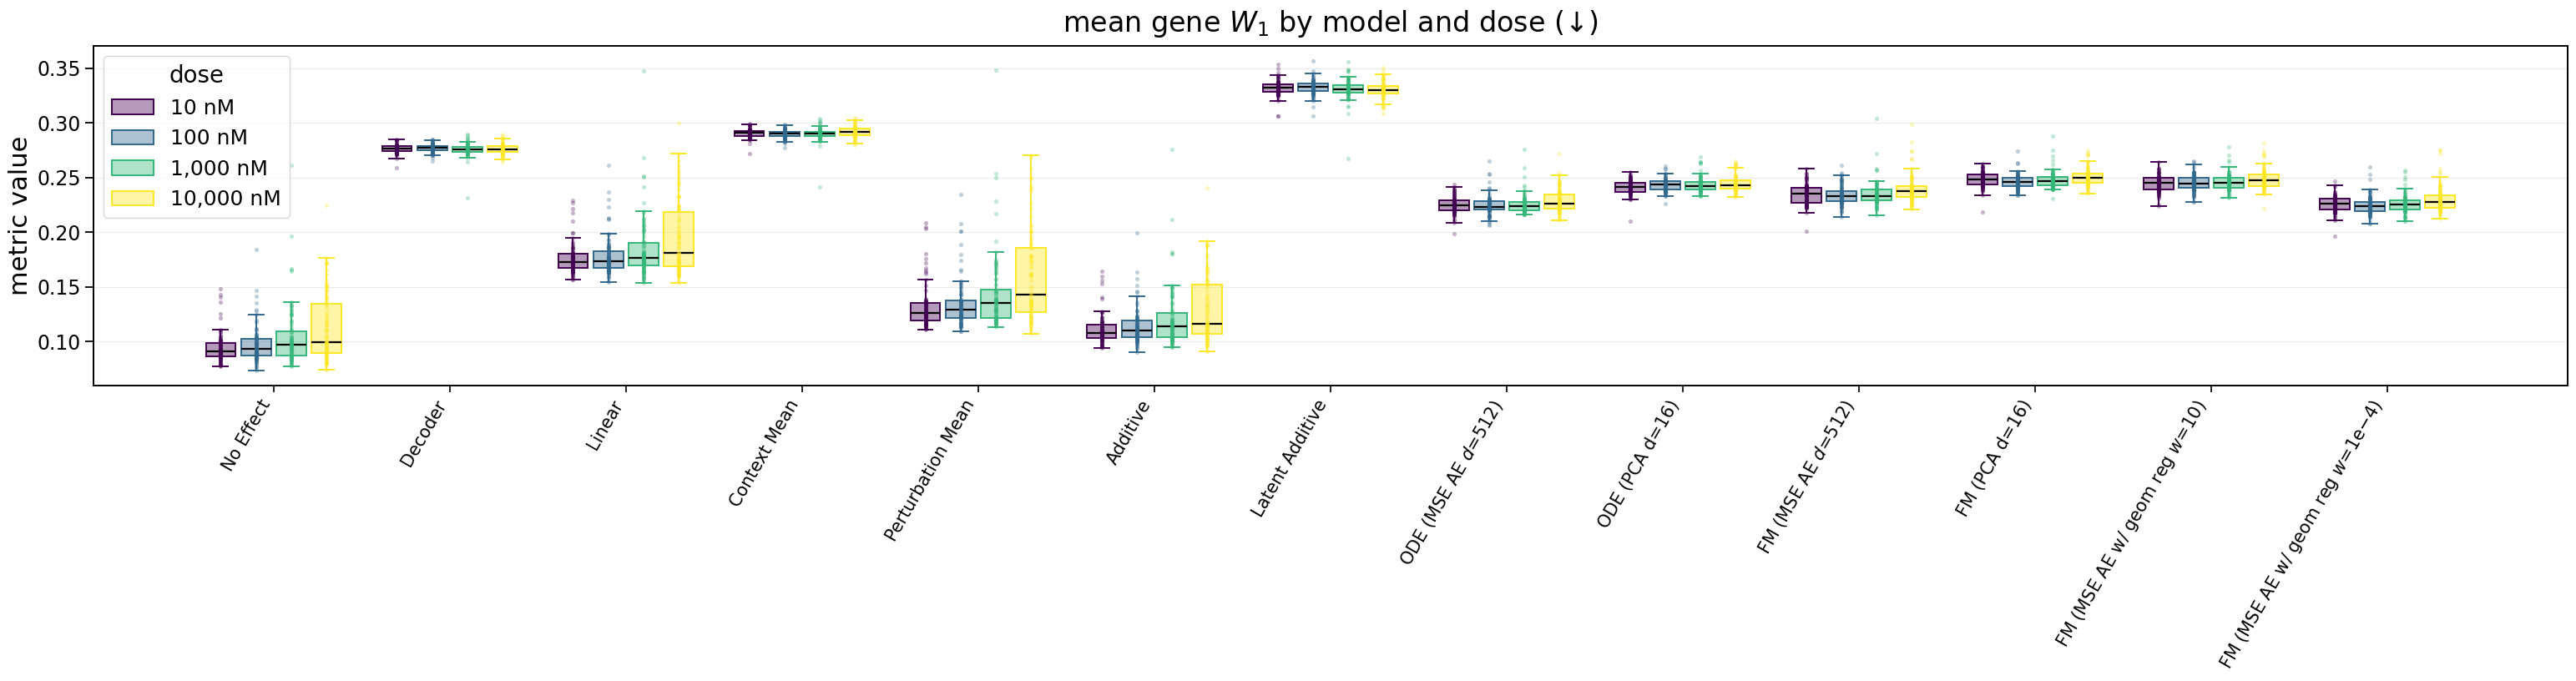

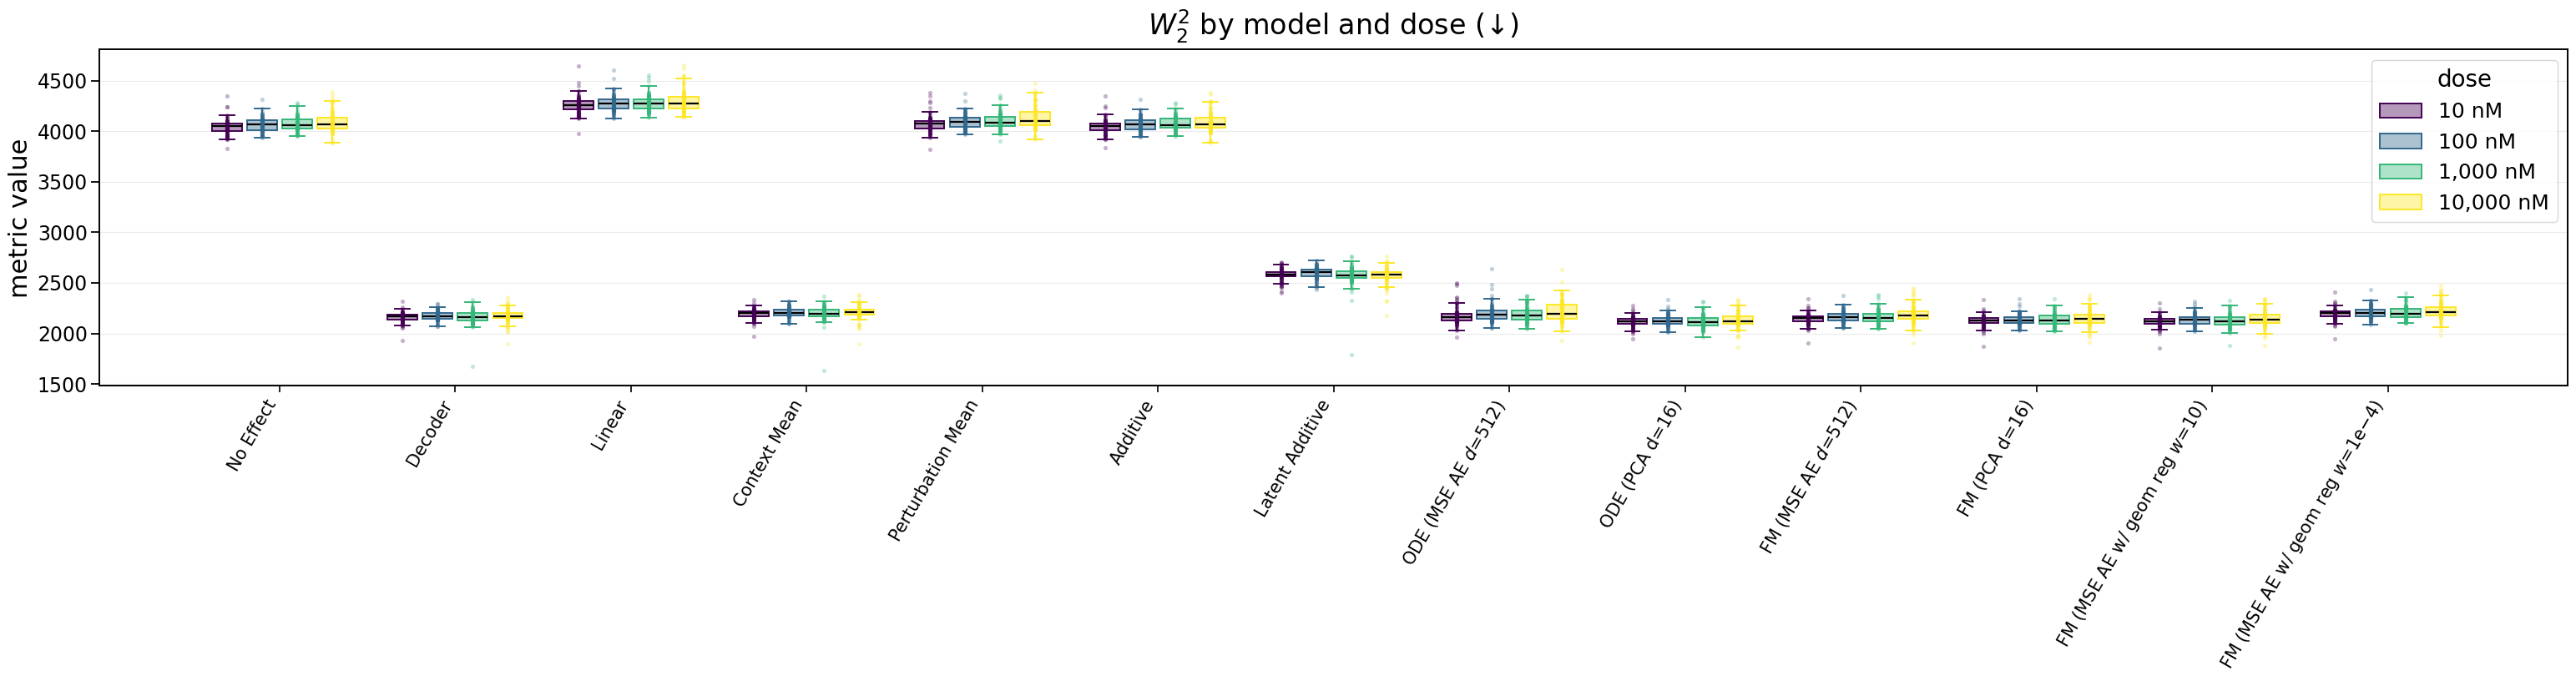

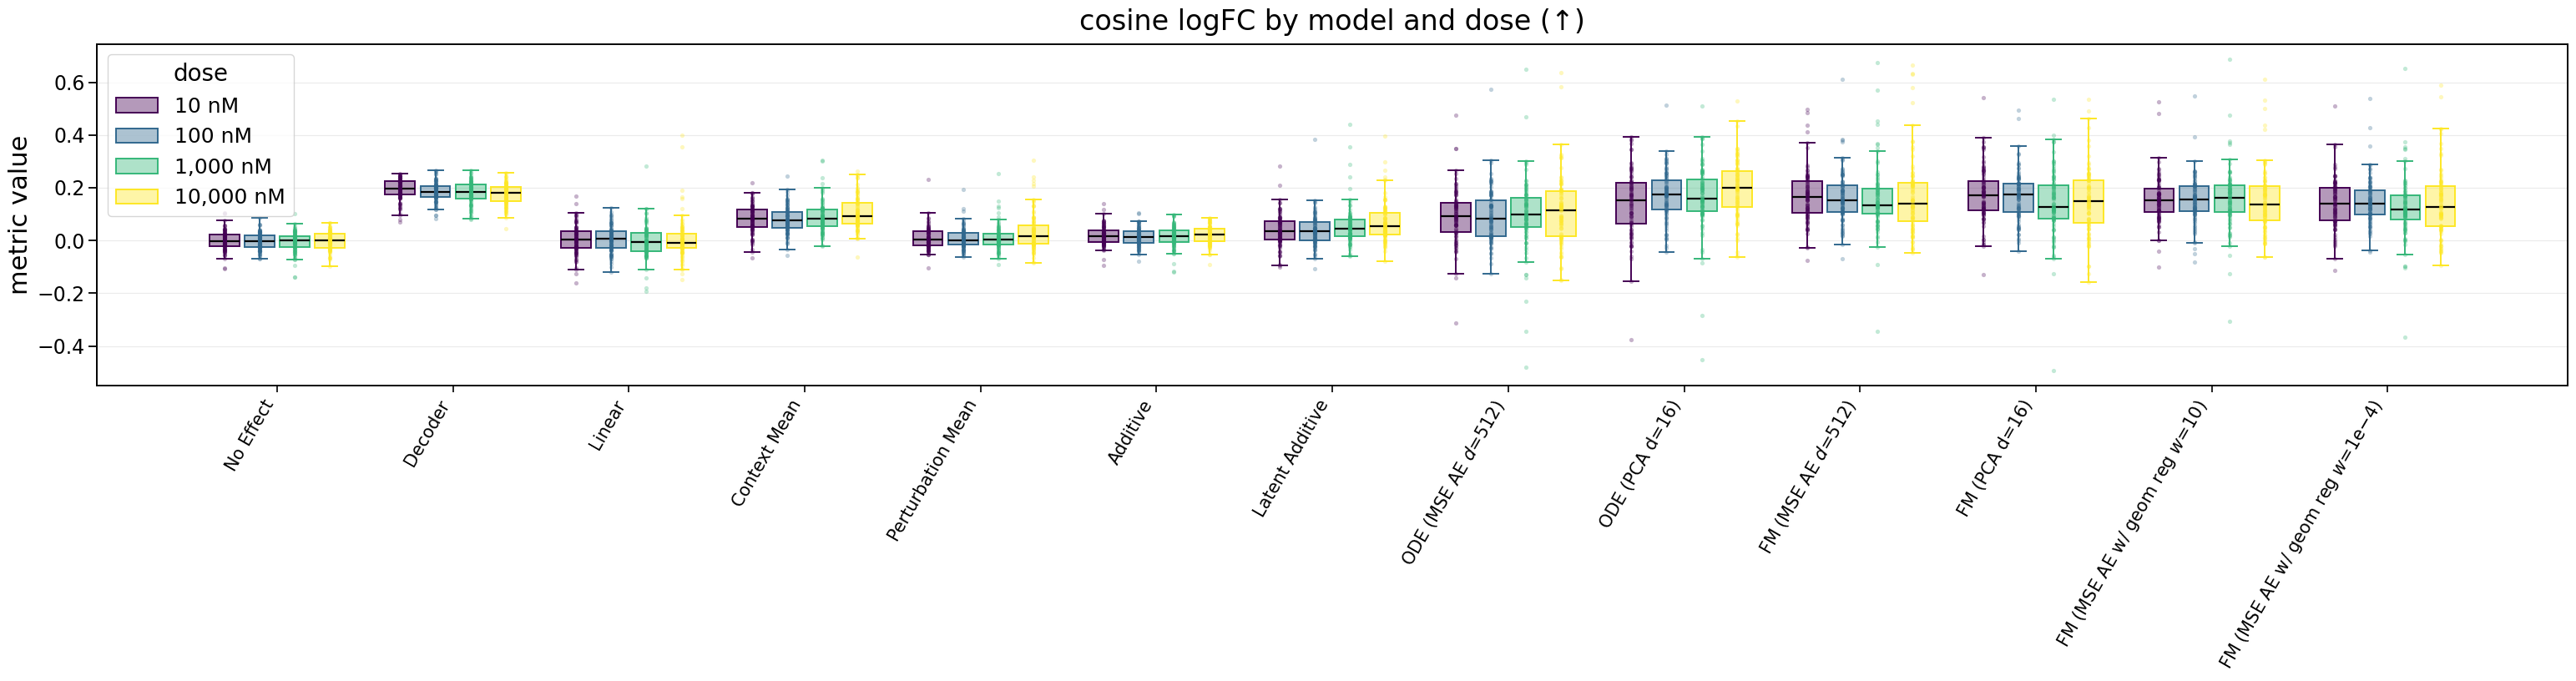

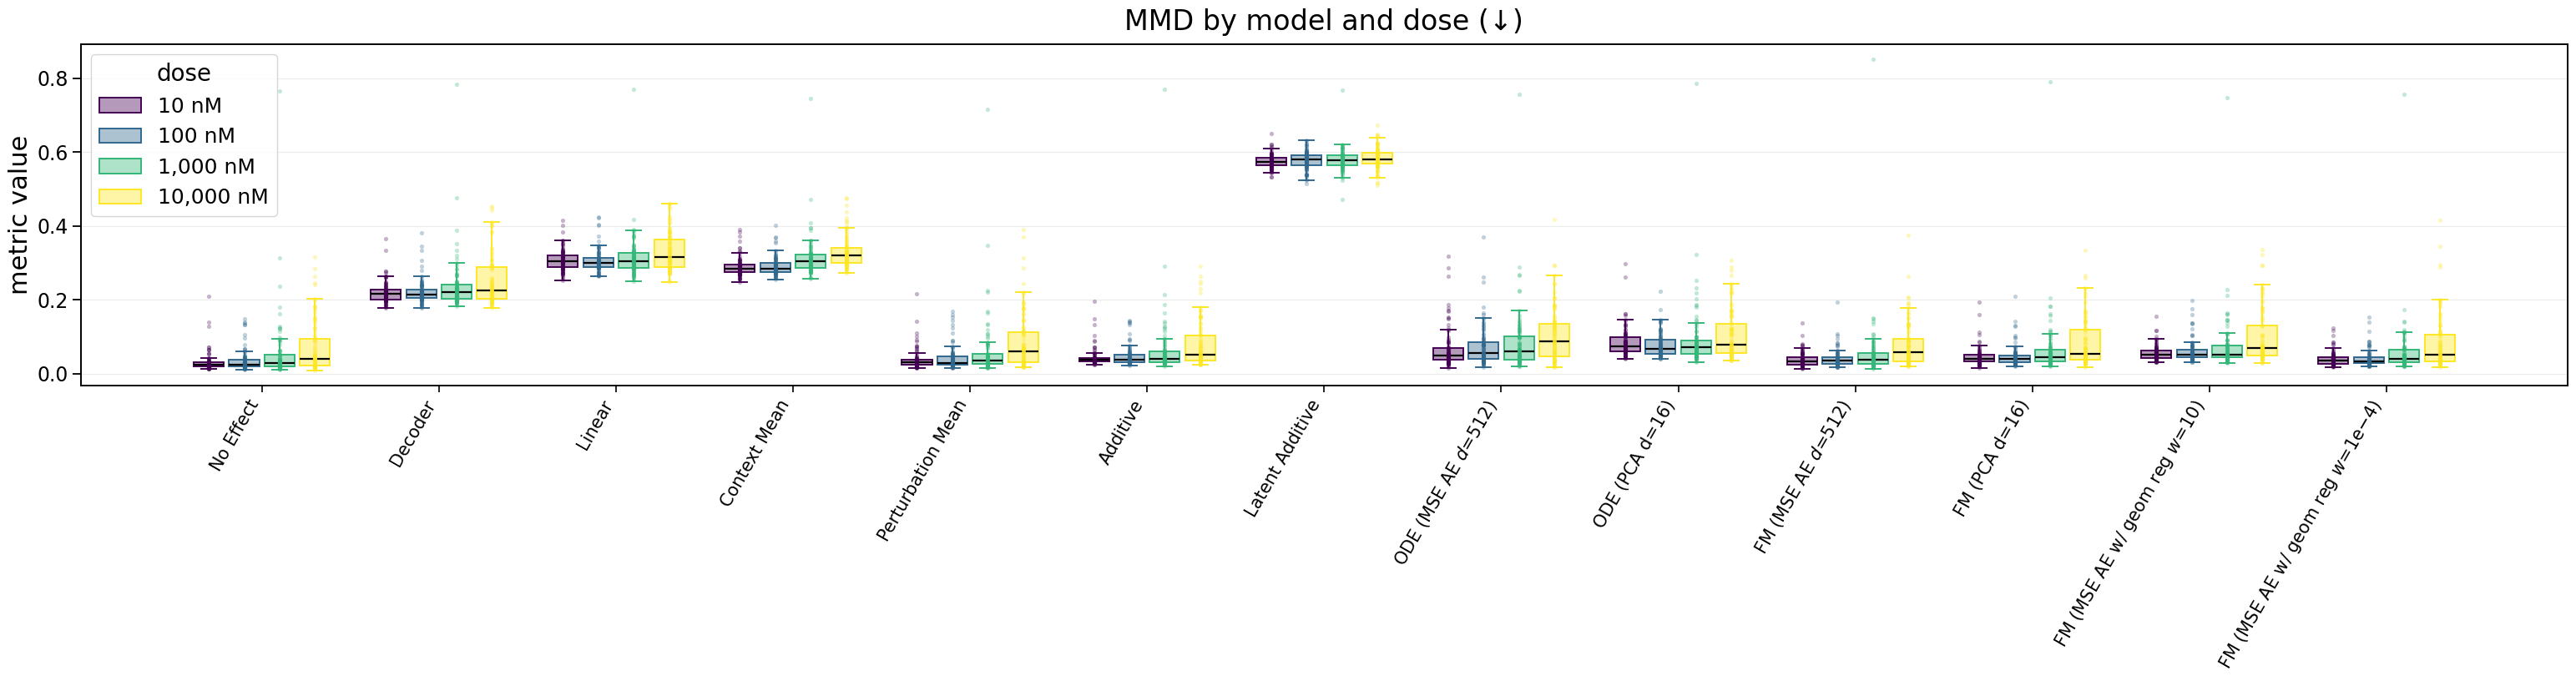

In [8]:
# poster-ready dose-stratified boxplots one figure per metric
# x-axis groups by model with one box per dose color-coded by dose
# uses display names group ordering and rc_context from the cell above
if per_group_metrics.empty or "product_dose" not in per_group_metrics.columns:
    print("dose boxplot skipped")
else:
    df = per_group_metrics.copy()
    df["dose"] = df["product_dose"].str.rsplit("_", n=1).str[-1].astype(int)
    dose_levels = sorted(df["dose"].unique())
    # viridis colormap so dose ordering reads as a perceptual gradient
    dose_colors = {dose: plt.cm.viridis(i / max(len(dose_levels) - 1, 1)) for i, dose in enumerate(dose_levels)}

    Path("figures").mkdir(exist_ok=True)

    with plt.rc_context(
        {
            "font.size": 18,
            "axes.titlesize": 24,
            "axes.labelsize": 22,
            "xtick.labelsize": 15,
            "ytick.labelsize": 17,
            "legend.fontsize": 18,
            "legend.title_fontsize": 20,
            "axes.linewidth": 1.6,
            "lines.linewidth": 2.2,
        }
    ):
        for metric in plot_metric_names:
            subset = df[df["metric_base"] == metric].copy()
            if subset.empty:
                subset = df[df["metric"] == metric].copy()
            if subset.empty:
                continue

            models = [m for m in all_models if m in set(subset["model_name"])]
            n_models = len(models)
            n_doses = len(dose_levels)
            width = 0.8 / n_doses

            fig, ax = plt.subplots(figsize=(max(2.4 * n_models, 12), 8.5))
            for d_idx, dose in enumerate(dose_levels):
                color = dose_colors[dose]
                positions = [m_idx + d_idx * width for m_idx in range(n_models)]
                box_data = [
                    subset.loc[(subset["model_name"] == model) & (subset["dose"] == dose), "value"].dropna().to_numpy()
                    for model in models
                ]
                bp = ax.boxplot(
                    box_data,
                    positions=positions,
                    widths=width * 0.85,
                    patch_artist=True,
                    showfliers=False,
                    manage_ticks=False,
                    medianprops=dict(color="black", linewidth=1.6),
                    boxprops=dict(linewidth=1.4),
                    whiskerprops=dict(linewidth=1.4),
                    capprops=dict(linewidth=1.4),
                )
                for patch in bp["boxes"]:
                    patch.set_facecolor((*color[:3], 0.4))
                    patch.set_edgecolor(color)
                for line in bp["whiskers"] + bp["caps"]:
                    line.set_color(color)
                for pos, values in zip(positions, box_data):
                    ax.scatter([pos] * len(values), values, s=14, alpha=0.30, color=color, zorder=3, linewidths=0)

            ax.set_xticks([m + (n_doses - 1) * width / 2 for m in range(n_models)])
            ax.set_xticklabels([_display_name(m) for m in models], rotation=60, ha="right")
            ax.set_ylabel("metric value")
            arrow = metric_direction_arrow.get(metric, "")
            pretty = metric_pretty.get(metric, metric)
            ax.set_title(f"{pretty} by model and dose ({arrow})", pad=12)
            ax.tick_params(axis="x", length=6, width=1.2)
            ax.tick_params(axis="y", length=7, width=1.3)
            for spine in ax.spines.values():
                spine.set_linewidth(1.4)
            ax.grid(alpha=0.25, linewidth=0.8, axis="y")

            ax.legend(
                [
                    plt.Rectangle((0, 0), 1, 1, fc=(*dose_colors[d][:3], 0.4), ec=dose_colors[d], linewidth=1.4)
                    for d in dose_levels
                ],
                [f"{d:,} nM" for d in dose_levels],
                title="dose",
                loc="best",
                frameon=True,
            )

            fig.tight_layout()
            plt.show()
            fig.savefig(f"figures/benchmark_dose_{metric}_poster.svg", bbox_inches="tight")
            fig.savefig(f"figures/benchmark_dose_{metric}_poster.pdf", bbox_inches="tight")


In [9]:
if not per_group_metrics.empty and "product_dose" in per_group_metrics.columns:
    df = per_group_metrics.copy()
    df["dose"] = df["product_dose"].str.rsplit("_", n=1).str[-1].astype(int)
    dose_levels = sorted(df["dose"].unique())
    models = sorted(df["model_name"].unique().tolist())

    for metric in plot_metric_names:
        subset = df[df["metric_base"] == metric]
        if subset.empty:
            subset = df[df["metric"] == metric]
        if subset.empty:
            continue

        rows = []
        for model in models:
            for dose in dose_levels:
                vals = subset.loc[(subset["model_name"] == model) & (subset["dose"] == dose), "value"].dropna()
                rows.append({"model": model, "dose": dose, "mean": vals.mean(), "std": vals.std()})

        tbl = pd.DataFrame(rows)
        pivot_mean = tbl.pivot(index="model", columns="dose", values="mean")
        pivot_std = tbl.pivot(index="model", columns="dose", values="std")

        lower = metric_lower_is_better.get(metric, True)
        best_per_dose = {d: pivot_mean[d].idxmin() if lower else pivot_mean[d].idxmax() for d in dose_levels}

        display_df = pd.DataFrame(index=pivot_mean.index)
        for dose in dose_levels:
            display_df[f"dose {dose}"] = [
                f"{pivot_mean.loc[m, dose]:.4f} \u00b1 {pivot_std.loc[m, dose]:.4f}" for m in pivot_mean.index
            ]
        display_df.index.name = "model"

        def _highlight_best_dose(col):
            dose = int(col.name.split()[-1])
            best_model = best_per_dose[dose]
            return ["font-weight: bold" if m == best_model else "" for m in col.index]

        arrow = "\u2193" if lower else "\u2191"
        display(
            display_df.style.apply(_highlight_best_dose, axis=0).set_caption(
                f"{metric} ({arrow}) mean \u00b1 std by dose (bold = best)"
            )
        )

,dose 10,dose 100,dose 1000,dose 10000
model,,,,
sciplex_deg_baseline_additive,0.1109 ± 0.0135,0.1135 ± 0.0162,0.1203 ± 0.0266,0.1291 ± 0.0298
sciplex_deg_baseline_context_mean,0.2905 ± 0.0039,0.2899 ± 0.0037,0.2902 ± 0.0065,0.2921 ± 0.0047
sciplex_deg_baseline_decoder,0.2764 ± 0.0039,0.2768 ± 0.0036,0.2759 ± 0.0061,0.2763 ± 0.0045
sciplex_deg_baseline_latent_additive,0.3323 ± 0.0068,0.3328 ± 0.0067,0.3311 ± 0.0097,0.3307 ± 0.0074
sciplex_deg_baseline_linear,0.1757 ± 0.0140,0.1777 ± 0.0173,0.1838 ± 0.0278,0.1944 ± 0.0324
sciplex_deg_baseline_no_effect,0.0940 ± 0.0137,0.0966 ± 0.0164,0.1035 ± 0.0270,0.1125 ± 0.0302
sciplex_deg_baseline_perturb_mean,0.1314 ± 0.0199,0.1346 ± 0.0222,0.1431 ± 0.0347,0.1592 ± 0.0414
sciplex_fm_deg_ae_latent_mse_d512,0.2345 ± 0.0094,0.2341 ± 0.0087,0.2351 ± 0.0111,0.2394 ± 0.0129
sciplex_fm_deg_geom_reg_w0p0001,0.2257 ± 0.0073,0.2247 ± 0.0083,0.2261 ± 0.0085,0.2307 ± 0.0120


,dose 10,dose 100,dose 1000,dose 10000
model,,,,
sciplex_deg_baseline_additive,4045.7906 ± 71.4983,4067.3794 ± 68.0545,4072.9719 ± 68.4046,4087.5718 ± 96.3947
sciplex_deg_baseline_context_mean,2192.5959 ± 48.9408,2209.5848 ± 44.2679,2197.1192 ± 79.1562,2210.8399 ± 66.5655
sciplex_deg_baseline_decoder,2159.4679 ± 48.6185,2176.3237 ± 44.9906,2161.5783 ± 73.7699,2172.7640 ± 66.3908
sciplex_deg_baseline_latent_additive,2580.5613 ± 58.6045,2596.7006 ± 56.8938,2569.7242 ± 104.8328,2570.2707 ± 83.9701
sciplex_deg_baseline_linear,4257.3629 ± 83.3665,4274.0191 ± 75.7323,4276.1051 ± 76.8547,4296.8873 ± 105.4387
sciplex_deg_baseline_no_effect,4040.6496 ± 71.7868,4062.3860 ± 68.5152,4068.9999 ± 69.2346,4085.6611 ± 99.2594
sciplex_deg_baseline_perturb_mean,4072.8211 ± 81.6550,4093.6388 ± 73.3375,4098.9422 ± 77.5060,4131.6579 ± 109.5582
sciplex_fm_deg_ae_latent_mse_d512,2145.7914 ± 55.3615,2164.4535 ± 54.7120,2162.2267 ± 65.1362,2185.2222 ± 88.9329
sciplex_fm_deg_geom_reg_w0p0001,2190.7208 ± 55.5264,2208.6187 ± 56.3009,2206.4570 ± 59.5162,2225.0263 ± 82.4753


,dose 10,dose 100,dose 1000,dose 10000
model,,,,
sciplex_deg_baseline_additive,0.0188 ± 0.0364,0.0145 ± 0.0337,0.0146 ± 0.0394,0.0214 ± 0.0345
sciplex_deg_baseline_context_mean,0.0820 ± 0.0528,0.0796 ± 0.0510,0.0895 ± 0.0587,0.1039 ± 0.0612
sciplex_deg_baseline_decoder,0.1926 ± 0.0402,0.1850 ± 0.0368,0.1816 ± 0.0415,0.1750 ± 0.0410
sciplex_deg_baseline_latent_additive,0.0395 ± 0.0609,0.0382 ± 0.0615,0.0567 ± 0.0754,0.0706 ± 0.0752
sciplex_deg_baseline_linear,0.0034 ± 0.0552,0.0046 ± 0.0485,-0.0031 ± 0.0622,0.0053 ± 0.0793
sciplex_deg_baseline_no_effect,-0.0001 ± 0.0365,-0.0030 ± 0.0315,-0.0054 ± 0.0387,-0.0016 ± 0.0329
sciplex_deg_baseline_perturb_mean,0.0086 ± 0.0427,0.0082 ± 0.0403,0.0109 ± 0.0480,0.0335 ± 0.0709
sciplex_fm_deg_ae_latent_mse_d512,0.1684 ± 0.1002,0.1637 ± 0.0966,0.1569 ± 0.1257,0.1669 ± 0.1457
sciplex_fm_deg_geom_reg_w0p0001,0.1405 ± 0.0939,0.1494 ± 0.0868,0.1244 ± 0.1173,0.1421 ± 0.1262


,dose 10,dose 100,dose 1000,dose 10000
model,,,,
sciplex_deg_baseline_additive,0.0438 ± 0.0256,0.0472 ± 0.0272,0.0642 ± 0.0858,0.0775 ± 0.0615
sciplex_deg_baseline_context_mean,0.2895 ± 0.0260,0.2914 ± 0.0254,0.3131 ± 0.0565,0.3291 ± 0.0437
sciplex_deg_baseline_decoder,0.2202 ± 0.0293,0.2216 ± 0.0332,0.2376 ± 0.0723,0.2515 ± 0.0672
sciplex_deg_baseline_latent_additive,0.5749 ± 0.0195,0.5777 ± 0.0237,0.5788 ± 0.0302,0.5828 ± 0.0289
sciplex_deg_baseline_linear,0.3075 ± 0.0290,0.3064 ± 0.0309,0.3132 ± 0.0577,0.3293 ± 0.0498
sciplex_deg_baseline_no_effect,0.0316 ± 0.0273,0.0354 ± 0.0296,0.0532 ± 0.0887,0.0706 ± 0.0700
sciplex_deg_baseline_perturb_mean,0.0378 ± 0.0285,0.0420 ± 0.0331,0.0597 ± 0.0856,0.0854 ± 0.0783
sciplex_fm_deg_ae_latent_mse_d512,0.0383 ± 0.0198,0.0409 ± 0.0242,0.0561 ± 0.0879,0.0779 ± 0.0613
sciplex_fm_deg_geom_reg_w0p0001,0.0399 ± 0.0202,0.0413 ± 0.0239,0.0585 ± 0.0789,0.0800 ± 0.0723


In [10]:
# multi-run aggregate (mean +/- std across training runs with matching config)
multi_run_summary = pd.concat(
    [df for df in [result.get("multi_run_summary"), result_pca.get("multi_run_summary")] if df is not None],
    ignore_index=True,
)
if not multi_run_summary.empty and (multi_run_summary["n_runs"] > 1).any():
    display(format_mean_std_table(multi_run_summary, metrics, metric_lower_is_better))
else:
    print("no multi-run data (each experiment has a single compatible run)")

no multi-run data (each experiment has a single compatible run)


In [11]:
# dynamic benchmark results LaTeX table
# filters to highest dose aggregates mean and std per (model metric)
# across perturbation groups and emits a sectioned table with bold
# best and underline second best computed globally per metric
#
# customize by editing
#   TABLE_METRICS to change which metrics appear or their formatting
#   TABLE_SECTION_ORDER to reorder sections
#   MODEL_SECTIONS to override auto section assignment
#   MODEL_DISPLAY_NAMES (above) to change row labels
#
# the builder is pure so you can run it on any subset of
# per_group_metrics or with a different metric spec

TABLE_METRICS = [
    # (metric_key, display_label, direction, mean_precision, std_precision)
    ("mean_gene_w1", r"Mean Gene $W_1$ ($\downarrow$)", "min", 2, 3),
    ("w2_squared", r"$W_2^2$ ($\downarrow$)", "min", 2, 3),
    ("cosine_log_fc", r"Cosine LogFC ($\uparrow$)", "max", 2, 3),
    ("mmd", r"MMD ($\downarrow$)", "min", 2, 3),
]

TABLE_SECTION_ORDER = ["Baselines", "ODE", "Flow Matching"]

# custom rotated label content per section unmapped sections render as
# \textit{<name>} on one line map to a stacked form for tall headers
# values are the full LaTeX that goes inside \rotatebox
SECTION_ROTATED_LABEL = {
    "Flow Matching": r"\shortstack{\textit{Flow} \\ \textit{Matching}}",
}

# explicit per-model section assignments unmapped models fall through
# to _auto_section below add entries here only to override the default
MODEL_SECTIONS = {}


def _auto_section(name: str) -> str:
    """infer the table section from the raw experiment name"""
    if "baseline" in name:
        return "Baselines"
    if "fisher_flow" in name:
        return "Flow Matching"
    if "_ode_" in name or "_ode" in name:
        return "ODE"
    if "_fm_" in name or "_fm" in name:
        return "Flow Matching"
    return "Other"


def _section_for(name: str) -> str:
    return MODEL_SECTIONS.get(name, _auto_section(name))


def _metric_col(df):
    return "metric_base" if "metric_base" in df.columns else "metric"


def build_benchmark_table(
    pgm,
    metrics_spec=TABLE_METRICS,
    section_order=TABLE_SECTION_ORDER,
    filter_highest_dose=True,
    label="tab:benchmark_results",
    extra_caption="on held-out K562 perturbations",
):
    """build the LaTeX benchmark results table from per_group_metrics

    Args:
        pgm: per_group_metrics with columns model_name value and a
            metric column (metric_base or metric) plus optionally
            product_dose and cell_type
        metrics_spec: list of tuples (metric_key, display_label,
            direction, mean_precision, std_precision) direction is
            min or max
        section_order: order of sections in the table sections not in
            this list appear at the end in discovery order
        filter_highest_dose: if True and product_dose is present only
            rows for the highest dose are used
        label: latex label for the table
        extra_caption: text appended to the default caption describing
            what data was evaluated

    Returns:
        the formatted LaTeX string ready to print
    """
    df = pgm.copy()
    dose_label = None
    if filter_highest_dose and "product_dose" in df.columns:
        df["_dose"] = df["product_dose"].str.rsplit("_", n=1).str[-1].astype(int)
        highest = df["_dose"].max()
        df = df[df["_dose"] == highest]
        dose_label = f"{highest:,}".replace(",", "{,}") + r"\,nM"

    mcol = _metric_col(df)
    models = sorted(df["model_name"].unique())

    # aggregate mean and std per (model metric) across groups
    agg_mean = {m: {} for m in models}
    agg_std = {m: {} for m in models}
    for model in models:
        for metric_key, *_ in metrics_spec:
            sub = df[(df["model_name"] == model) & (df[mcol] == metric_key)]
            vals = sub["value"].dropna().to_numpy()
            if len(vals) == 0:
                agg_mean[model][metric_key] = float("nan")
                agg_std[model][metric_key] = float("nan")
            else:
                agg_mean[model][metric_key] = float(vals.mean())
                agg_std[model][metric_key] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0

    # best and second best per metric across all models
    best_model = {}
    second_model = {}
    for metric_key, _, direction, *_ in metrics_spec:
        pairs = [(m, agg_mean[m][metric_key]) for m in models if not pd.isna(agg_mean[m][metric_key])]
        if not pairs:
            continue
        reverse = direction == "max"
        pairs.sort(key=lambda p: p[1], reverse=reverse)
        best_model[metric_key] = pairs[0][0]
        if len(pairs) > 1:
            second_model[metric_key] = pairs[1][0]

    # section assignment and per-section sort by first metric value
    # ascending for min metrics descending for max metrics
    models_by_section = {}
    for m in models:
        models_by_section.setdefault(_section_for(m), []).append(m)

    first_key, _, first_dir, *_ = metrics_spec[0]
    reverse_first = first_dir == "max"
    for sec in models_by_section:
        models_by_section[sec].sort(
            key=lambda m: agg_mean[m][first_key] if not pd.isna(agg_mean[m][first_key]) else float("inf"),
            reverse=reverse_first,
        )

    ordered_sections = [s for s in section_order if models_by_section.get(s)]
    ordered_sections += [s for s in models_by_section if s not in section_order]

    def fmt_cell(model, metric_key, precision, std_precision):
        mean = agg_mean[model][metric_key]
        std = agg_std[model][metric_key]
        if pd.isna(mean):
            return "--"
        s = f"{mean:.{precision}f} $\\pm$ {std:.{std_precision}f}"
        if best_model.get(metric_key) == model:
            return r"\textbf{" + s + "}"
        if second_model.get(metric_key) == model:
            return r"\underline{" + s + "}"
        return s

    n_metric_cols = len(metrics_spec)
    col_spec = "cl" + "c" * n_metric_cols
    caption_body = "Benchmark results"
    if dose_label is not None:
        caption_body += f" at highest dose ({dose_label})"
    if extra_caption:
        caption_body += " " + extra_caption
    caption = (
        caption_body
        + r". Mean $\pm$ std across perturbations. "
        + r"\textbf{Bold} = best, \underline{underline} = second best per metric."
    )

    lines = [
        r"\begin{table}[ht]",
        r"\centering",
        r"\caption{" + caption + "}",
        r"\label{" + label + "}",
        r"\resizebox{\textwidth}{!}{%",
        r"\begin{tabular}{" + col_spec + "}",
        r"\toprule",
        "& Model & " + " & ".join(h for _, h, *_ in metrics_spec) + r" \\",
        r"\midrule",
    ]

    for si, section in enumerate(ordered_sections):
        mods = models_by_section.get(section, [])
        if not mods:
            continue
        if si > 0:
            lines.append(r"\midrule")
        n = len(mods)
        for ri, model in enumerate(mods):
            cells = [fmt_cell(model, k, p, sp) for k, _, _, p, sp in metrics_spec]
            display = MODEL_DISPLAY_NAMES.get(model, model)
            if ri == 0:
                label_inner = SECTION_ROTATED_LABEL.get(section, r"\textit{" + section + r"}")
                mr = r"\multirow{" + str(n) + r"}{*}{\rotatebox[origin=c]{90}{" + label_inner + r"}}"
                lines.append(mr + " & " + display + " & " + " & ".join(cells) + r" \\")
            else:
                lines.append("& " + display + " & " + " & ".join(cells) + r" \\")

    lines += [
        r"\bottomrule",
        r"\end{tabular}%",
        r"}",
        r"\end{table}",
    ]

    return "\n".join(lines)


print(build_benchmark_table(per_group_metrics))


\begin{table}[ht]
\centering
\caption{Benchmark results at highest dose (10{,}000\,nM) on held-out K562 perturbations. Mean $\pm$ std across perturbations. \textbf{Bold} = best, \underline{underline} = second best per metric.}
\label{tab:benchmark_results}
\resizebox{\textwidth}{!}{%
\begin{tabular}{clcccc}
\toprule
& Model & Mean Gene $W_1$ ($\downarrow$) & $W_2^2$ ($\downarrow$) & Cosine LogFC ($\uparrow$) & MMD ($\downarrow$) \\
\midrule
\multirow{7}{*}{\rotatebox[origin=c]{90}{\textit{Baselines}}} & No Effect & \textbf{0.11 $\pm$ 0.030} & 4085.66 $\pm$ 99.259 & -0.00 $\pm$ 0.033 & \textbf{0.07 $\pm$ 0.070} \\
& Additive & \underline{0.13 $\pm$ 0.030} & 4087.57 $\pm$ 96.395 & 0.02 $\pm$ 0.035 & \underline{0.08 $\pm$ 0.061} \\
& Perturbation Mean & 0.16 $\pm$ 0.041 & 4131.66 $\pm$ 109.558 & 0.03 $\pm$ 0.071 & 0.09 $\pm$ 0.078 \\
& Linear & 0.19 $\pm$ 0.032 & 4296.89 $\pm$ 105.439 & 0.01 $\pm$ 0.079 & 0.33 $\pm$ 0.050 \\
& Decoder & 0.28 $\pm$ 0.005 & 2172.76 $\pm$ 66.391 & \underline

## metric vs perturbation effect strength

for each perturbation group, x = perturbation effect strength (L2 norm of mean logFC
between ground truth perturbed and control cells), y = model metric value. interactive
plotly scatter with model traces toggleable.

In [12]:
# use no_effect baseline W2^2 per group as perturbation effect strength proxy
# (no_effect predicts control cells, so its W2^2 = distance between perturbed and control distributions)
no_effect_w2 = per_group_metrics[
    (per_group_metrics["model_name"] == "sciplex_deg_baseline_no_effect")
    & ((per_group_metrics["metric_base"] == "w2_squared") | (per_group_metrics["metric"] == "w2_squared"))
][["cell_type", "product_dose", "value"]].rename(columns={"value": "effect_strength"})

if no_effect_w2.empty:
    raise ValueError("no_effect baseline or w2_squared not found - make sure both are in experiments list")

effect_df = no_effect_w2.drop_duplicates(subset=["cell_type", "product_dose"]).reset_index(drop=True)
print(f"effect strength (no_effect W2^2) for {len(effect_df)} groups")
print(f"range: {effect_df['effect_strength'].min():.2f} - {effect_df['effect_strength'].max():.2f}")
display(effect_df.describe().round(1))


effect strength (no_effect W2^2) for 375 groups
range: 3827.58 - 4393.08


,effect_strength
count,375.0
mean,4064.4
std,79.5
min,3827.6
25%,4016.6
50%,4056.1
75%,4098.6
max,4393.1


In [13]:
import plotly.express as px

# merge effect strength with per-group metrics
pg = per_group_metrics.merge(
    effect_df[["cell_type", "product_dose", "effect_strength"]], on=["cell_type", "product_dose"], how="left"
)

# extract dose from product_dose for hover
pg["dose"] = pg["product_dose"].str.rsplit("_", n=1).str[-1].astype(int)
pg["drug"] = pg["product_dose"].str.rsplit("_", n=1).str[0]

for metric in plot_metric_names:
    subset = pg[pg["metric_base"] == metric].copy()
    if subset.empty:
        subset = pg[pg["metric"] == metric].copy()
    if subset.empty:
        continue

    direction = metric_direction.get(metric, "")
    fig = px.scatter(
        subset,
        x="effect_strength",
        y="value",
        color="model_name",
        hover_data=["drug", "dose", "cell_type"],
        opacity=0.5,
        title=f"{metric} vs perturbation effect strength  ({direction})",
        labels={
            "effect_strength": "perturbation effect strength (||logFC||₂)",
            "value": metric,
            "model_name": "model",
        },
    )
    fig.update_traces(marker_size=5)
    fig.update_layout(height=500, width=900, legend=dict(font=dict(size=9)))
    fig.show()